2026-04-22 17:57:56.628699: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776880676.908734      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776880676.995780      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776880677.737549      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776880677.737595      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776880677.737599      55 computation_placer.cc:177] computation placer alr

✅ Using dataset: /kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals
Found 960 images belonging to 20 classes.
Found 240 images belonging to 20 classes.
Classes: {'bear': 0, 'bison': 1, 'boar': 2, 'cow': 3, 'coyote': 4, 'deer': 5, 'dog': 6, 'elephant': 7, 'fox': 8, 'goat': 9, 'horse': 10, 'kangaroo': 11, 'leopard': 12, 'lion': 13, 'ox': 14, 'pig': 15, 'sheep': 16, 'tiger': 17, 'wolf': 18, 'zebra': 19}


2026-04-22 17:58:30.137541: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 60s 823ms/step - accuracy: 0.1138 - loss: 3.6996 - val_accuracy: 0.5000 - val_loss: 1.8638
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 678ms/step - accuracy: 0.4913 - loss: 1.6620 - val_accuracy: 0.6958 - val_loss: 1.1350
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 675ms/step - accuracy: 0.6906 - loss: 1.0239 - val_accuracy: 0.7500 - val_loss: 0.9108
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 668ms/step - accuracy: 0.7779 - loss: 0.7566 - val_accuracy: 0.7667 - val_loss: 0.8479
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 675ms/step - accuracy: 0.8101 - loss: 0.6481 - val_accuracy: 0.7792 - val_loss: 0.7700
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 43s 717ms/step - accuracy: 0.8506 - loss: 0.4746 - val_accuracy: 0.8208 - val_loss: 0.7195
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 671ms/step - accuracy: 0.8888 - loss: 0.3898 - val_accuracy: 0.8333 - val_loss: 0.7339
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 679ms/step - accuracy: 0.8949 - loss: 0.3414 - val_accu

✅ Model saved as .h5 successfully!


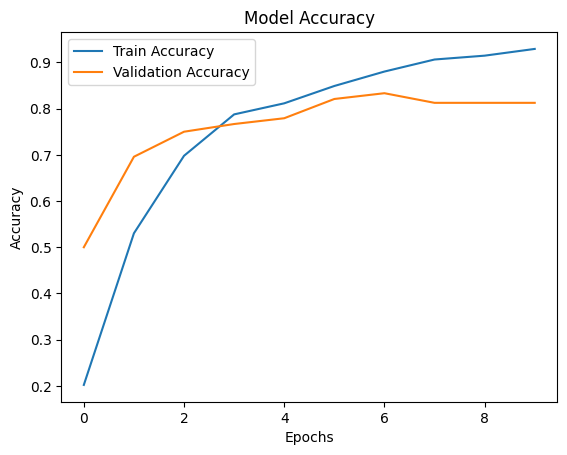

In [1]:
# ==========================================================
# 🔹 1. IMPORTS
# ==========================================================
import os
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ==========================================================
# 🔹 2. DATASET PATH
# ==========================================================
SOURCE = "/kaggle/input/datasets/iamsouravbanerjee/animal-image-dataset-90-different-animals/animals/animals"

print("✅ Using dataset:", SOURCE)

# ==========================================================
# 🔹 3. SELECTED CLASSES
# ==========================================================
selected_classes = [
    "bear","bison","boar","cow","coyote","deer","dog","elephant",
    "fox","goat","horse","kangaroo","leopard","lion","ox",
    "pig","sheep","tiger","wolf","zebra"
]

# ==========================================================
# 🔹 4. DATA LOADING
# ==========================================================
IMG_SIZE = 224
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    SOURCE,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    classes=selected_classes
)

val_data = datagen.flow_from_directory(
    SOURCE,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    classes=selected_classes
)

print("Classes:", train_data.class_indices)

# ==========================================================
# 🔹 5. MODEL (FINE-TUNED)
# ==========================================================
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(len(selected_classes), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# ==========================================================
# 🔹 6. COMPILE
# ==========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================================
# 🔹 7. TRAIN
# ==========================================================
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# ==========================================================
# 🔹 8. PRINT ACCURACY
# ==========================================================
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n🎯 Final Training Accuracy: {train_acc * 100:.2f}%")
print(f"🎯 Final Validation Accuracy: {val_acc * 100:.2f}%")

# ==========================================================
# 🔹 9. SAVE MODEL AS .H5 (SAFE METHOD)
# ==========================================================
# Step 1: Save in new format
model.save("/kaggle/working/temp_model.keras")

# Step 2: Reload
model = tf.keras.models.load_model("/kaggle/working/temp_model.keras")

# Step 3: Save as .h5
model.save("/kaggle/working/animalmodel.h5", save_format='h5')

# Save labels
with open("/kaggle/working/labels.txt", "w") as f:
    for label in selected_classes:
        f.write(label + "\n")

print("✅ Model saved as .h5 successfully!")

# ==========================================================
# 🔹 10. PLOT GRAPH
# ==========================================================
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

